# 01 — Exploratory Data Analysis
**RetailPulse** · Online Retail II dataset (UCI)

Transactions from a UK online gift retailer, 2009-12-01 → 2011-12-09.
Goal of this notebook: understand structure, data-quality issues, and the
sales / customer patterns that drive the modelling choices later.

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

raw = pd.read_parquet('../data/raw/online_retail_II.parquet')
print(raw.shape)
raw.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Structure & missing values

In [5]:
display(raw.dtypes)
miss = raw.isna().sum()
pd.DataFrame({'missing': miss, 'pct': (miss/len(raw)*100).round(2)})

Invoice        string[python]
StockCode      string[python]
Description    string[python]
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country        string[python]
dtype: object

,missing,pct
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


- **Customer ID** missing on ~22.8% of rows → those lines can't be used for RFM / churn.
- **Description** missing on ~0.4% of rows.
- No missing dates, quantities, or prices.

## 2. Data-quality flags

In [6]:
canc = raw['Invoice'].astype(str).str.startswith('C')
print('Cancellations      :', f'{canc.sum():,}')
print('Negative quantity  :', f'{(raw.Quantity<0).sum():,}')
print('Price <= 0         :', f'{(raw.Price<=0).sum():,}')
print('Exact duplicates   :', f'{raw.duplicated().sum():,}')
raw[['Quantity','Price']].describe()

Cancellations      : 19,494
Negative quantity  : 22,950
Price <= 0         : 6,207
Exact duplicates   : 34,335


,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


Extreme min/max on Quantity (±80,995) and Price come from bulk orders,
cancellations, and manual adjustments — handled in `src/preprocessing.py`.

## 3. Load the cleaned tables

In [7]:
tx    = pd.read_parquet('../data/processed/transactions.parquet')
daily = pd.read_parquet('../data/processed/daily_sales.parquet')
rfm   = pd.read_parquet('../data/processed/rfm.parquet')
print('transactions', tx.shape, '| daily', daily.shape, '| rfm', rfm.shape)

transactions (776579, 10) | daily (739, 4) | rfm (5852, 9)


## 4. Revenue over time

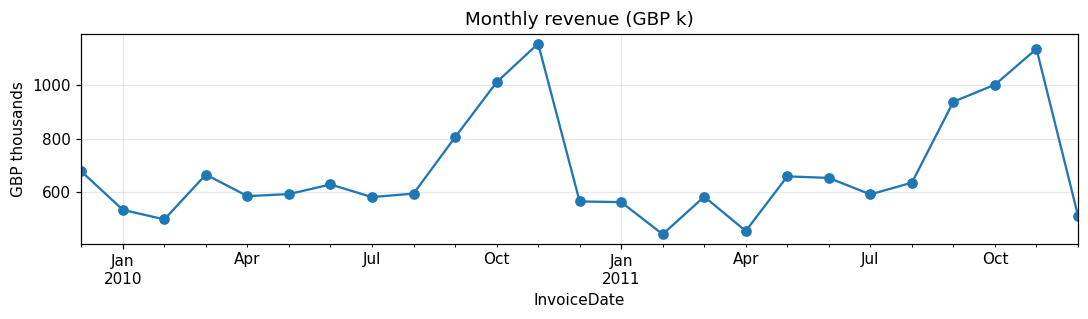

In [8]:
m = tx.set_index('InvoiceDate').TotalPrice.resample('MS').sum()/1e3
ax = m.plot(marker='o', figsize=(10,3), title='Monthly revenue (GBP k)')
ax.set_ylabel('GBP thousands'); plt.tight_layout()

## 5. Weekly & hourly seasonality

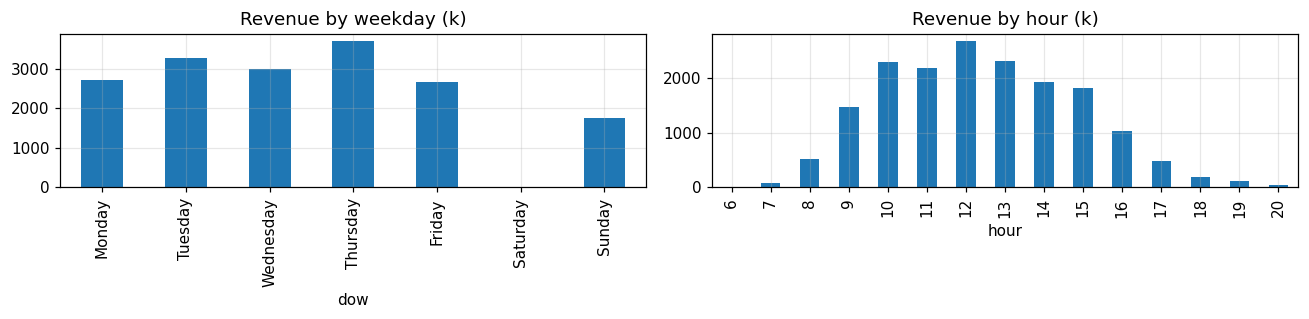

In [9]:
tx = tx.assign(dow=tx.InvoiceDate.dt.day_name(), hour=tx.InvoiceDate.dt.hour)
order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig,ax=plt.subplots(1,2,figsize=(12,3))
(tx.groupby('dow').TotalPrice.sum()/1e3).reindex(order).plot.bar(ax=ax[0], title='Revenue by weekday (k)')
(tx.groupby('hour').TotalPrice.sum()/1e3).plot.bar(ax=ax[1], title='Revenue by hour (k)')
plt.tight_layout()

**Key finding:** almost no revenue on **Saturdays** (the retailer doesn't
process weekend orders) and a lunchtime peak (10:00–13:00). Prophet's weekly
seasonality will need to capture the Saturday drop.

## 6. Top products & markets

In [10]:
display(tx.groupby('Description').TotalPrice.sum().nlargest(10).round(0))
tx.groupby('Country').TotalPrice.sum().nlargest(10).round(0)

Description
REGENCY CAKESTAND 3 TIER              277656.0
WHITE HANGING HEART T-LIGHT HOLDER    247048.0
PAPER CRAFT , LITTLE BIRDIE           168470.0
JUMBO BAG RED RETROSPOT               134307.0
ASSORTED COLOUR BIRD ORNAMENT         124352.0
PARTY BUNTING                         103283.0
MEDIUM CERAMIC TOP STORAGE JAR         81417.0
PAPER CHAIN KIT 50'S CHRISTMAS         76598.0
CHILLI LIGHTS                          69084.0
JUMBO BAG STRAWBERRY                   64128.0
Name: TotalPrice, dtype: float64

Country
United Kingdom    14288774.0
EIRE                586626.0
Netherlands         549773.0
Germany             383289.0
France              309403.0
Australia           167800.0
Spain                97767.0
Switzerland          93401.0
Sweden               86045.0
Denmark              67423.0
Name: TotalPrice, dtype: float64

## 7. RFM feature distributions

,Recency,Frequency,Monetary
count,5852.0,5852.0,5852.0
mean,200.2,6.3,2916.7
std,208.5,12.7,14306.9
min,1.0,1.0,3.0
25%,25.0,1.0,339.6
50%,95.0,3.0,856.0
75%,379.0,7.0,2241.0
max,739.0,373.0,580987.0


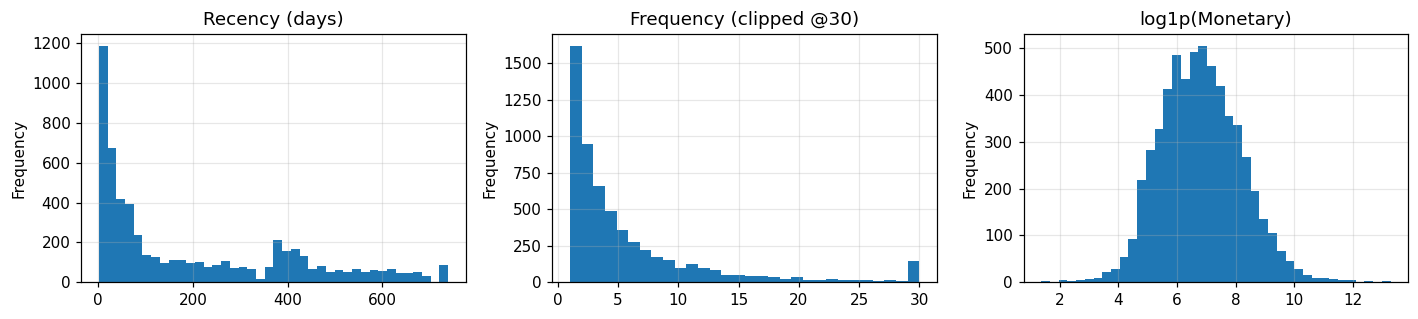

In [11]:
fig,ax=plt.subplots(1,3,figsize=(13,3))
rfm.Recency.plot.hist(bins=40, ax=ax[0], title='Recency (days)')
rfm.Frequency.clip(upper=30).plot.hist(bins=30, ax=ax[1], title='Frequency (clipped @30)')
np.log1p(rfm.Monetary).plot.hist(bins=40, ax=ax[2], title='log1p(Monetary)')
plt.tight_layout()
rfm[['Recency','Frequency','Monetary']].describe().round(1)

## Takeaways
1. Keep only valid, customer-attributed product sales for RFM/churn (72.8% of rows retained).
2. Strong weekly seasonality with a Saturday gap → feed to Prophet.
3. Monetary is heavily right-skewed → log-transform before KMeans.
4. UK dominates (~85% of revenue); a handful of EU countries follow.